# 📊 Descriptive Statistics Exercise
## World Happiness Report 2026
---

> **Petunjuk Umum:**  
> - Isi setiap cell kode di bawah ini.  
> - Tulis interpretasi Anda di cell Markdown yang telah disediakan (bertanda ✏️).  
> - Jangan hapus cell yang sudah ada — tambahkan cell baru jika diperlukan.  
> - Pastikan semua cell sudah dijalankan sebelum mengumpulkan.

---
## ⚙️ Import Library

In [1]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# Plot settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Library berhasil di-import')


Library berhasil di-import


---
# Bagian 1 – Data Preparation & Eksplorasi Awal
Sebelum melakukan analisis, kita perlu memahami struktur dataset dan memastikan data siap digunakan.

## Task 1.1 – Load & Inspect Dataset

**a.** Download *Data for Table 2.1* dari [https://www.worldhappiness.report/data-sharing/](https://www.worldhappiness.report/data-sharing/)
lalu load ke dalam DataFrame bernama `df_whr`.

In [2]:
# a. Load dataset ke dalam df_whr
# Ganti path di bawah sesuai lokasi file Anda
df_whr = pd.read_excel('WHR26_Data_Figure_2.1.xlsx')

print(f'Shape dataset: {df_whr.shape}')

Shape dataset: (2116, 13)


**b.** Tampilkan 5 baris pertama dan 5 baris terakhir dataset.

In [3]:
# b. Tampilkan 5 baris pertama
display(df_whr.head())

# 5 baris terakhir
display(df_whr.tail())

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
2111,2011,152,Burundi,3.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2112,2011,153,Sierra Leone,3.586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2113,2011,154,Central African Republic,3.568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2114,2011,155,Benin,3.493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2115,2011,156,Togo,3.007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**c.** Cek dimensi dataset.

In [4]:
# c. Dimensi dataset
print(f'Jumlah baris  : {df_whr.shape[0]}')
print(f'Jumlah kolom  : {df_whr.shape[1]}')

Jumlah baris  : 2116
Jumlah kolom  : 13


**d.** Tampilkan daftar kolom beserta tipe datanya.

In [5]:
# d. Info kolom dan tipe data
df_whr.info()

<class 'pandas.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   str    
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by: Generosit

**e.** Cek missing values — tampilkan jumlah dan persentasenya.

In [6]:
# e. Missing values
missing = pd.DataFrame({
    'Jumlah Missing': df_whr.isnull().sum(),
    'Persentase (%)': (
        df_whr.isnull().sum() / len(df_whr) * 100
    ).round(2)
})

display(missing)

,Jumlah Missing,Persentase (%)
Year,0,0.00
Rank,0,0.00
Country name,0,0.00
Life evaluation (3-year average),0,0.00
Lower whisker,1094,51.70
Upper whisker,1094,51.70
Explained by: Log GDP per capita,1097,51.84
Explained by: Social support,1097,51.84
Explained by: Healthy life expectancy,1100,51.98
Explained by: Freedom to make life choices,1099,51.94


**f.** Buat DataFrame `df_idn` yang hanya berisi data Indonesia tahun **2021–2025** sesuai periode analisis presentasi, lalu reset index-nya.


In [7]:
# f. Filter data Indonesia tahun 2021–2025
# Periode ini digunakan konsisten untuk seluruh analisis presentasi.
df_idn = df_whr[
    (df_whr['Country name'] == 'Indonesia') &
    (df_whr['Year'].between(2021, 2025))
].reset_index(drop=True)

print('Jumlah data Indonesia:', len(df_idn))

display(
    df_idn[['Year', 'Rank', 'Life evaluation (3-year average)']]
)


Jumlah data Indonesia: 5


,Year,Rank,Life evaluation (3-year average)
0,2025,87,5.617
1,2024,83,5.617
2,2023,80,5.568
3,2022,84,5.277
4,2021,87,5.240


## Task 1.2 – Klasifikasi Variabel

**a.** Jelaskan perbedaan variabel **Kualitatif** dan **Kuantitatif**,  
beserta sub-kategori masing-masing (Nominal, Ordinal, Diskrit, Kontinu).

✏️ **Jawaban:**

- **Kualitatif**: variabel yang berisi kategori atau label.
  - **Nominal**: kategori yang tidak memiliki urutan, misalnya nama negara.
  - **Ordinal**: kategori yang memiliki urutan, misalnya peringkat.
- **Kuantitatif**: variabel yang berupa angka dan dapat digunakan dalam perhitungan statistik.
  - **Diskrit**: nilai yang dapat dihitung dan umumnya berupa bilangan bulat, misalnya tahun.
  - **Kontinu**: nilai hasil pengukuran yang dapat memiliki angka desimal, misalnya Life Evaluation.


**b & c.** Klasifikasikan semua kolom `df_idn` ke dalam tabel klasifikasi.

In [8]:
# b & c. Tabel klasifikasi semua kolom df_idn
klasifikasi = pd.DataFrame({
    'nama_kolom': df_idn.columns.tolist(),
    'tipe_variabel': [
        'Kuantitatif - Diskrit',      # Year
        'Kualitatif - Ordinal',      # Rank
        'Kualitatif - Nominal',      # Country name
        'Kuantitatif - Kontinu',     # Life evaluation
        'Kuantitatif - Kontinu',     # Lower whisker
        'Kuantitatif - Kontinu',     # Upper whisker
        'Kuantitatif - Kontinu',     # Log GDP
        'Kuantitatif - Kontinu',     # Social support
        'Kuantitatif - Kontinu',     # Healthy life expectancy
        'Kuantitatif - Kontinu',     # Freedom
        'Kuantitatif - Kontinu',     # Generosity
        'Kuantitatif - Kontinu',     # Corruption
        'Kuantitatif - Kontinu'      # Dystopia + residual
    ],
    'alasan': [
        'Tahun berupa bilangan bulat dan dapat dihitung.',
        'Peringkat memiliki urutan dari posisi lebih tinggi ke lebih rendah.',
        'Nama negara adalah kategori tanpa urutan.',
        'Nilai evaluasi kehidupan dapat berupa desimal.',
        'Batas bawah merupakan nilai numerik kontinu.',
        'Batas atas merupakan nilai numerik kontinu.',
        'Kontribusi GDP berupa nilai numerik/desimal.',
        'Kontribusi social support berupa nilai numerik/desimal.',
        'Kontribusi healthy life expectancy berupa nilai numerik/desimal.',
        'Kontribusi freedom berupa nilai numerik/desimal.',
        'Kontribusi generosity berupa nilai numerik/desimal.',
        'Kontribusi persepsi korupsi berupa nilai numerik/desimal.',
        'Residual merupakan nilai numerik/desimal.'
    ]
})
display(klasifikasi)


,nama_kolom,tipe_variabel,alasan
0,Year,Kuantitatif - Diskrit,Tahun berupa bilangan bulat dan dapat dihitung.
1,Rank,Kualitatif - Ordinal,Peringkat memiliki urutan dari posisi lebih ti...
2,Country name,Kualitatif - Nominal,Nama negara adalah kategori tanpa urutan.
3,Life evaluation (3-year average),Kuantitatif - Kontinu,Nilai evaluasi kehidupan dapat berupa desimal.
4,Lower whisker,Kuantitatif - Kontinu,Batas bawah merupakan nilai numerik kontinu.
5,Upper whisker,Kuantitatif - Kontinu,Batas atas merupakan nilai numerik kontinu.
6,Explained by: Log GDP per capita,Kuantitatif - Kontinu,Kontribusi GDP berupa nilai numerik/desimal.
7,Explained by: Social support,Kuantitatif - Kontinu,Kontribusi social support berupa nilai numerik...
8,Explained by: Healthy life expectancy,Kuantitatif - Kontinu,Kontribusi healthy life expectancy berupa nila...
9,Explained by: Freedom to make life choices,Kuantitatif - Kontinu,Kontribusi freedom berupa nilai numerik/desimal.


✏️ **Jawaban:**

Klasifikasi variabel penting karena jenis variabel menentukan metode statistik dan visualisasi yang sesuai. Variabel kuantitatif dapat digunakan untuk perhitungan seperti mean, median, standar deviasi, dan korelasi, sedangkan variabel kualitatif lebih sesuai untuk pengelompokan atau perbandingan kategori.


---
# Bagian 2 – Measure of Central Tendency
Ukuran pemusatan merangkum seluruh data dengan **satu nilai representatif**.
Tiga ukuran utama: **Mean**, **Median**, dan **Mode**.

## Task 2.1 – Konsep & Implementasi Central Tendency

**a.** Hitung Mean, Median, dan Mode untuk kolom `Life evaluation (3-year average)`.


In [9]:
# a. Central Tendency — Life Ladder
col = 'Life evaluation (3-year average)'

mean_ll = df_idn[col].mean()
median_ll = df_idn[col].median()
mode_ll = df_idn[col].mode().iloc[0]

print(f"Mean   : {mean_ll:.4f}")
print(f"Median : {median_ll:.4f}")
print(f"Mode   : {mode_ll:.4f}")

Mean   : 5.4638
Median : 5.5680
Mode   : 5.6170


✏️ **Jawaban:**

Mean dan median dapat digunakan sebagai ukuran pusat karena keduanya memberikan gambaran nilai tipikal data. Pada periode 2021–2025, mean sebesar **5.4638** dan median sebesar **5.5680**. Karena jumlah observasi hanya lima dan terdapat perubahan nilai antar tahun, median juga berguna sebagai ukuran yang lebih tahan terhadap nilai yang relatif tinggi/rendah. Untuk pelaporan deskriptif, mean dan median sebaiknya ditampilkan bersama.


**d.** Tampilkan central tendency semua kolom numerik sekaligus.

In [10]:
# d. Statistik deskriptif lengkap semua kolom numerik
numeric_cols = df_idn.select_dtypes(include='number').columns.tolist()

numeric_cols.remove('Year')

central = pd.DataFrame({
    'Mean': df_idn[numeric_cols].mean(),
    'Median': df_idn[numeric_cols].median(),
    'Mode': df_idn[numeric_cols].mode().iloc[0]
}).round(4)

display(central)

,Mean,Median,Mode
Rank,84.2000,84.000,87.000
Life evaluation (3-year average),5.4638,5.568,5.617
Lower whisker,5.3598,5.466,5.139
Upper whisker,5.5676,5.670,5.341
Explained by: Log GDP per capita,1.3854,1.382,1.288
Explained by: Social support,1.1674,1.184,0.883
Explained by: Healthy life expectancy,0.4528,0.472,0.314
Explained by: Freedom to make life choices,0.8046,0.779,0.620
Explained by: Generosity,0.3814,0.399,0.295
Explained by: Perceptions of corruption,0.0434,0.044,0.033


**e.** Bandingkan Mean `Life evaluation` Indonesia dengan rata-rata global pada tahun 2021–2025.


,Indonesia,Global Mean,Selisih
Year,,,
2025,5.617,5.6499,-0.0329
2024,5.617,5.5782,0.0388
2023,5.568,5.5276,0.0404
2022,5.277,5.5398,-0.2628
2021,5.240,5.5536,-0.3136


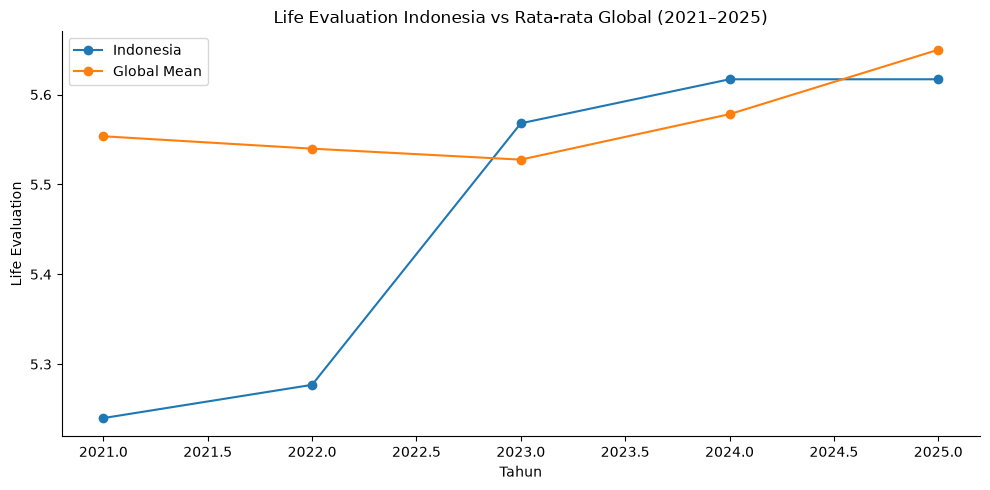

In [11]:
# e. Perbandingan Indonesia vs global per tahun
life_col = 'Life evaluation (3-year average)'

global_mean = (
    df_whr[df_whr['Year'].between(2021, 2025)]
    .groupby('Year')[life_col]
    .mean()
)

idn_mean = df_idn.set_index('Year')[life_col]

comparison = pd.concat(
    [idn_mean.rename('Indonesia'), global_mean.rename('Global Mean')],
    axis=1
)
comparison['Selisih'] = comparison['Indonesia'] - comparison['Global Mean']

display(comparison.round(4))

# Visualisasi perbandingan
comparison[['Indonesia', 'Global Mean']].plot(
    marker='o', figsize=(10, 5)
)
plt.title('Life Evaluation Indonesia vs Rata-rata Global (2021–2025)')
plt.xlabel('Tahun')
plt.ylabel('Life Evaluation')
plt.legend()
plt.tight_layout()
plt.show()


✏️ **Interpretasi:**

Pada 2021–2022, Life Evaluation Indonesia berada di bawah rata-rata global. Pada 2023–2024, nilainya sedikit di atas rata-rata global. Pada 2025, Indonesia kembali sedikit berada di bawah rata-rata global. Dengan demikian, posisi Indonesia relatif terhadap rata-rata global mengalami fluktuasi selama periode pengamatan.


---
# Bagian 3 – Measure of Spread (Dispersi)
Ukuran penyebaran mengukur seberapa jauh data tersebar dari nilai pusatnya.

## Task 3.1 – Analisis Dispersi Data Indonesia

**a.** Hitung semua ukuran dispersi untuk `Life Ladder`.

In [12]:
# a. Ukuran dispersi — Life Ladder
data = df_idn['Life evaluation (3-year average)']

q1 = data.quantile(0.25)
q3 = data.quantile(0.75)

iqr = q3 - q1
std = data.std()

dispersi = {
    'Range': data.max() - data.min(),
    'Variance': data.var(),
    'Standard Deviation': std,
    'IQR': iqr,
    'Coefficient of Variation (%)':
        std / data.mean() * 100
}

for key, value in dispersi.items():
    print(f"{key}: {value:.4f}")

Range: 0.3770
Variance: 0.0357
Standard Deviation: 0.1889
IQR: 0.3400
Coefficient of Variation (%): 3.4579


**c.** ✏️ Bandingkan Standard Deviation Life Evaluation Indonesia dengan variasi rata-rata global tahunan 2021–2025. Apa artinya bagi konsistensi data?


In [13]:
# c. Std Dev Indonesia vs variasi rata-rata global tahunan
std_idn = df_idn['Life evaluation (3-year average)'].std()
std_global_mean = (
    df_whr[df_whr['Year'].between(2021, 2025)]
    .groupby('Year')['Life evaluation (3-year average)']
    .mean()
    .std()
)

print(f'Std Dev Indonesia              : {std_idn:.4f}')
print(f'Std Dev rata-rata global/tahun : {std_global_mean:.4f}')


Std Dev Indonesia              : 0.1889
Std Dev rata-rata global/tahun : 0.0485


**d.** Hitung IQR untuk semua kolom numerik. Kolom mana yang memiliki sebaran terbesar?

In [14]:
# d. IQR semua kolom numerik
iqr_all = (
    df_idn[numeric_cols].quantile(0.75)
    -
    df_idn[numeric_cols].quantile(0.25)
)

display(
    iqr_all.sort_values(
        ascending=False
    ).rename('IQR').to_frame().round(4)
)

,IQR
Rank,4.000
Lower whisker,0.355
Life evaluation (3-year average),0.340
Upper whisker,0.325
Explained by: Freedom to make life choices,0.255
Explained by: Generosity,0.099
Dystopia + residual,0.082
Explained by: Social support,0.060
Explained by: Healthy life expectancy,0.031
Explained by: Log GDP per capita,0.023


**e.** Hitung CV semua kolom numerik. Kolom mana yang paling stabil?

In [15]:
# e. Coefficient of Variation semua kolom numerik
cv_all = (
    df_idn[numeric_cols].std()
    /
    df_idn[numeric_cols].mean()
    * 100
)

display(
    cv_all.sort_values()
    .rename('CV (%)')
    .to_frame()
    .round(2)
)

,CV (%)
Upper whisker,3.33
Life evaluation (3-year average),3.46
Rank,3.50
Lower whisker,3.60
Explained by: Log GDP per capita,5.83
Dystopia + residual,9.99
Explained by: Social support,15.25
Explained by: Healthy life expectancy,18.51
Explained by: Generosity,18.69
Explained by: Perceptions of corruption,19.46


✏️ **Jawaban:**

Standard deviation Life Evaluation Indonesia sebesar **0.1889**, sedangkan standard deviation rata-rata global antar tahun sebesar **0.0485**. Artinya, perubahan Life Evaluation Indonesia selama 2021–2025 lebih bervariasi dibandingkan perubahan rata-rata global antar tahun. Perbandingan ini mengukur variasi deret waktu, bukan penyebaran seluruh negara pada satu tahun.


## Task 3.2 – Deteksi & Analisis Outlier

**a.** Deteksi outlier `Life Ladder` menggunakan metode **IQR**.

In [16]:
# a. Deteksi outlier — metode IQR
data = df_idn['Life evaluation (3-year average)']

q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers_iqr = df_idn[
    (data < lower) |
    (data > upper)
]

print("Batas bawah:", round(lower, 4))
print("Batas atas :", round(upper, 4))
print("Jumlah outlier:", len(outliers_iqr))

display(
    outliers_iqr[
        ['Year', 'Life evaluation (3-year average)']
    ]
)

Batas bawah: 4.767
Batas atas : 6.127
Jumlah outlier: 0


,Year,Life evaluation (3-year average)


**b.** Deteksi outlier menggunakan **Z-Score** (|z| > 3). Bandingkan hasilnya.

In [17]:
# b. Deteksi outlier — metode Z-Score
z_scores = np.abs(
    stats.zscore(
        df_idn['Life evaluation (3-year average)']
    )
)

outliers_zscore = df_idn[z_scores > 3]

print(
    "Jumlah outlier Z-Score:",
    len(outliers_zscore)
)

display(
    outliers_zscore[
        ['Year', 'Life evaluation (3-year average)']
    ]
)

Jumlah outlier Z-Score: 0


,Year,Life evaluation (3-year average)


**c.** Visualisasi outlier dengan Boxplot.

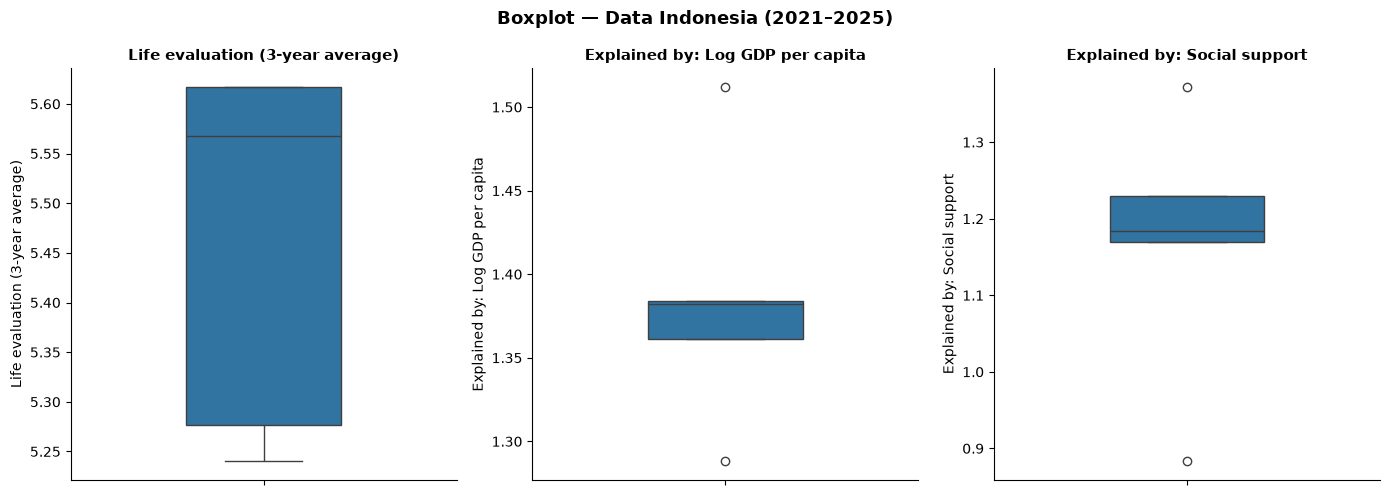

In [18]:
# c. Boxplot — tiga variabel utama yang tersedia pada dataset
cols_box = [
    'Life evaluation (3-year average)',
    'Explained by: Log GDP per capita',
    'Explained by: Social support'
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, c in zip(axes, cols_box):
    sns.boxplot(y=df_idn[c], ax=ax, width=0.4)
    ax.set_title(c, fontsize=11, fontweight='bold')
    ax.set_xlabel('')

fig.suptitle('Boxplot — Data Indonesia (2021–2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**d.** ✏️ **Interpretasi outlier:**

Berdasarkan metode IQR, **tidak terdapat outlier** pada Life Evaluation Indonesia selama 2021–2025. Metode Z-Score juga tidak menemukan outlier dengan batas |z| > 3. Karena tidak ada outlier, tidak ada tahun yang perlu dianggap sebagai penyimpangan ekstrem pada periode ini.


---
# Bagian 4 – Analisis Distribusi Data
Distribusi data menggambarkan pola penyebaran nilai — apakah simetris, skewed kanan, atau skewed kiri.

## Task 4.1 – Eksplorasi Distribusi

**a.** Buat Histogram untuk semua kolom numerik dalam satu figure.

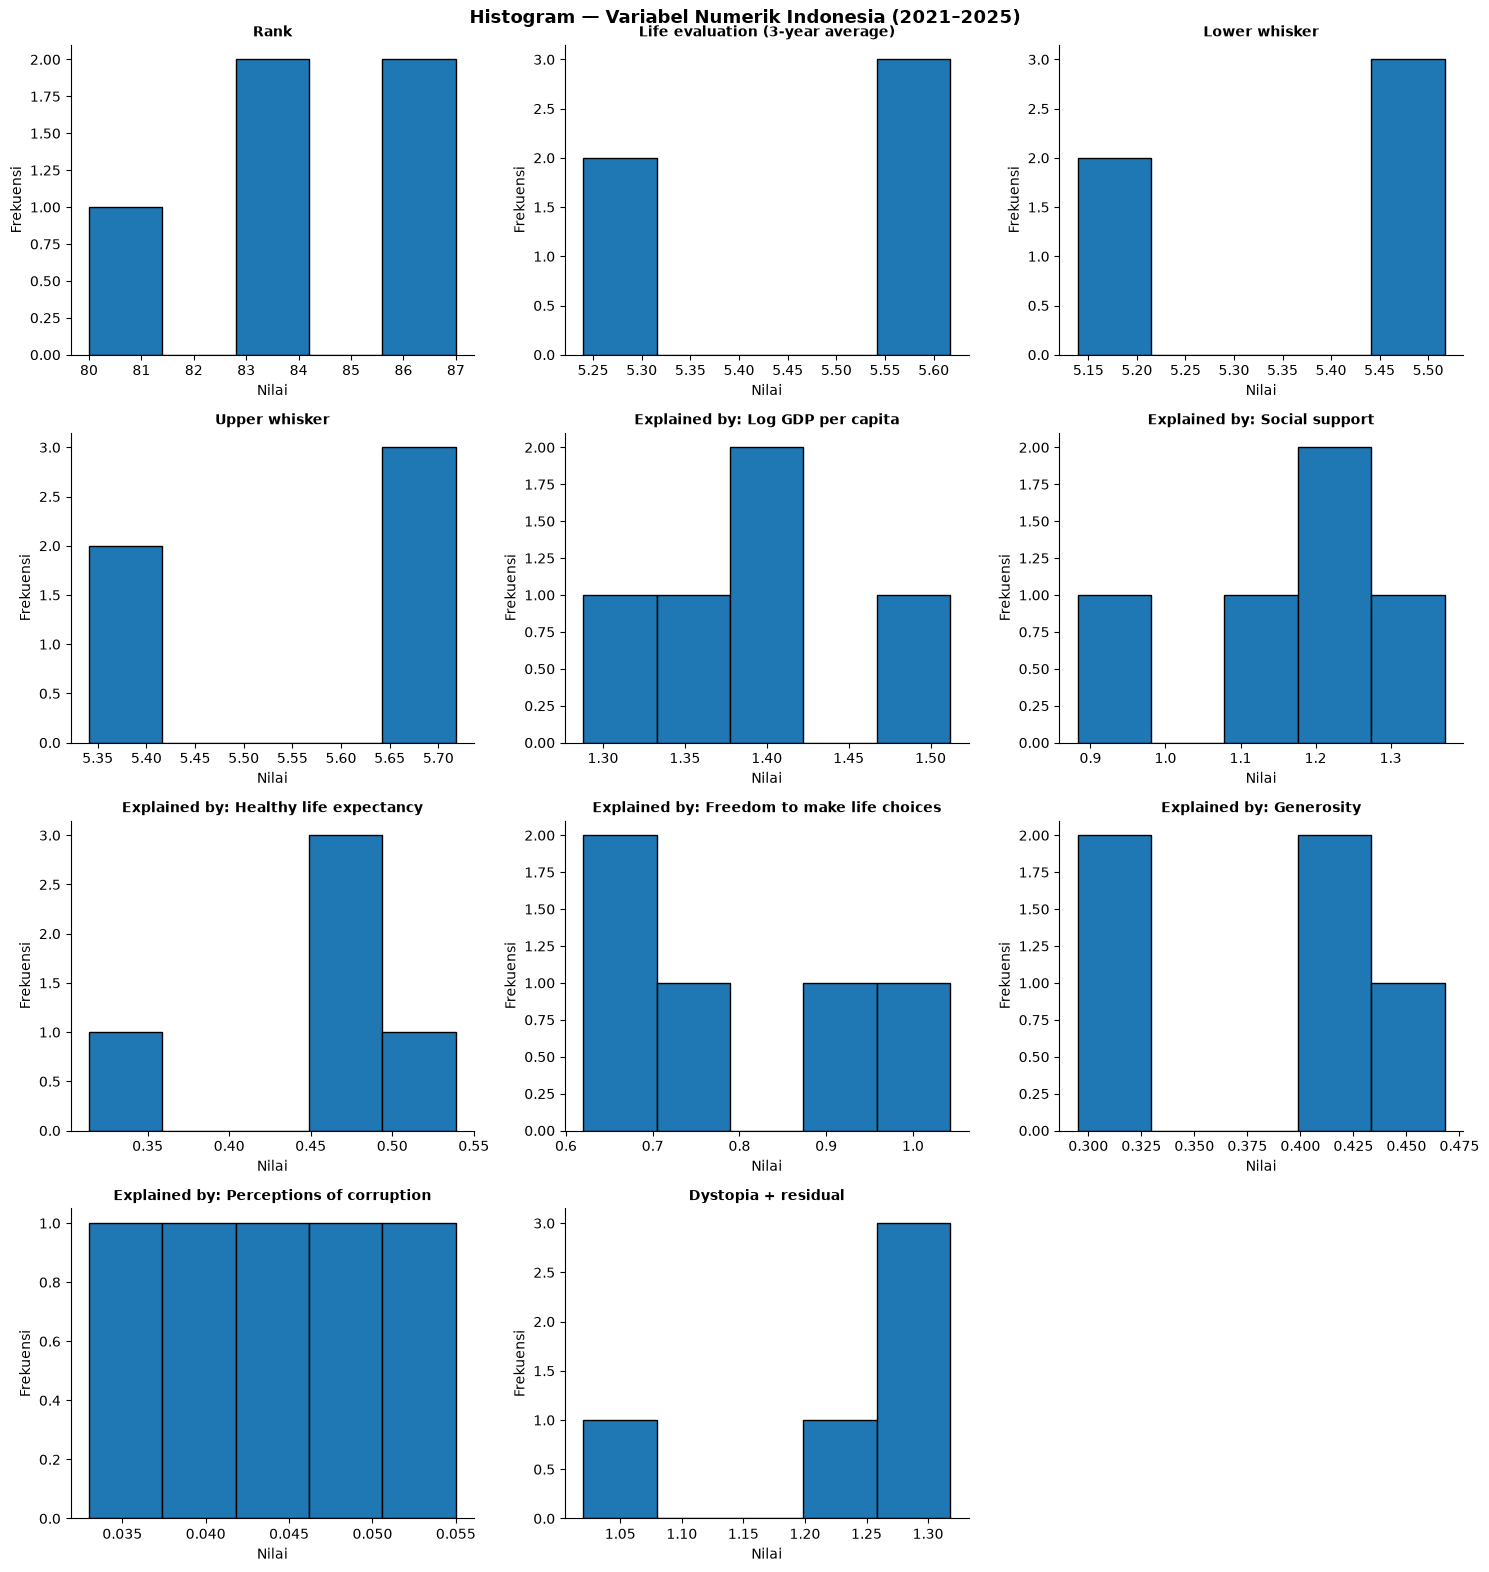

In [19]:
# a. Histogram semua kolom numerik
n = len(numeric_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = np.array(axes).flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_idn[col].dropna(), bins=5, edgecolor='black')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Histogram — Variabel Numerik Indonesia (2021–2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**b.** Hitung Skewness dan Kurtosis setiap kolom numerik.

In [20]:
# b. Skewness dan Kurtosis
core_cols = [
    'Life evaluation (3-year average)',
    'Explained by: Log GDP per capita',
    'Explained by: Social support',
    'Explained by: Healthy life expectancy',
    'Explained by: Freedom to make life choices',
    'Explained by: Generosity',
    'Explained by: Perceptions of corruption'
]

skew_kurt = pd.DataFrame({
    'Skewness': df_idn[core_cols].skew(),
    'Kurtosis': df_idn[core_cols].kurt()
}).round(4)

display(skew_kurt)


,Skewness,Kurtosis
Life evaluation (3-year average),-0.5811,-3.1477
Explained by: Log GDP per capita,0.8609,2.1766
Explained by: Social support,-1.0481,2.3328
Explained by: Healthy life expectancy,-1.4102,2.8280
Explained by: Freedom to make life choices,0.4449,-1.5987
Explained by: Generosity,-0.1406,-1.8848
Explained by: Perceptions of corruption,0.2252,-0.4210


✏️ **Interpretasi skewness:**

Gunakan aturan sederhana: skewness > 0,5 = right-skewed; skewness < -0,5 = left-skewed; dan -0,5 sampai 0,5 = relatif symmetric.

| Kolom | Skewness | Jenis Distribusi | Interpretasi |
|---|---:|---|---|
| Life Evaluation | -0.5811 | Left-skewed | Ekor distribusi cenderung lebih panjang ke kiri. |
| Log GDP | 0.8609 | Right-skewed | Ekor distribusi cenderung lebih panjang ke kanan. |
| Social support | -1.0481 | Left-skewed | Ekor distribusi cenderung lebih panjang ke kiri. |
| Healthy life expectancy | -1.4102 | Left-skewed | Ekor distribusi cenderung lebih panjang ke kiri. |
| Freedom | 0.4449 | Symmetric | Relatif mendekati simetris. |
| Generosity | -0.1406 | Symmetric | Relatif mendekati simetris. |
| Perceptions of corruption | 0.2252 | Symmetric | Relatif mendekati simetris. |


**d.** Buat KDE Plot overlay di atas Histogram untuk `Life Ladder` dan `Log GDP per capita`.

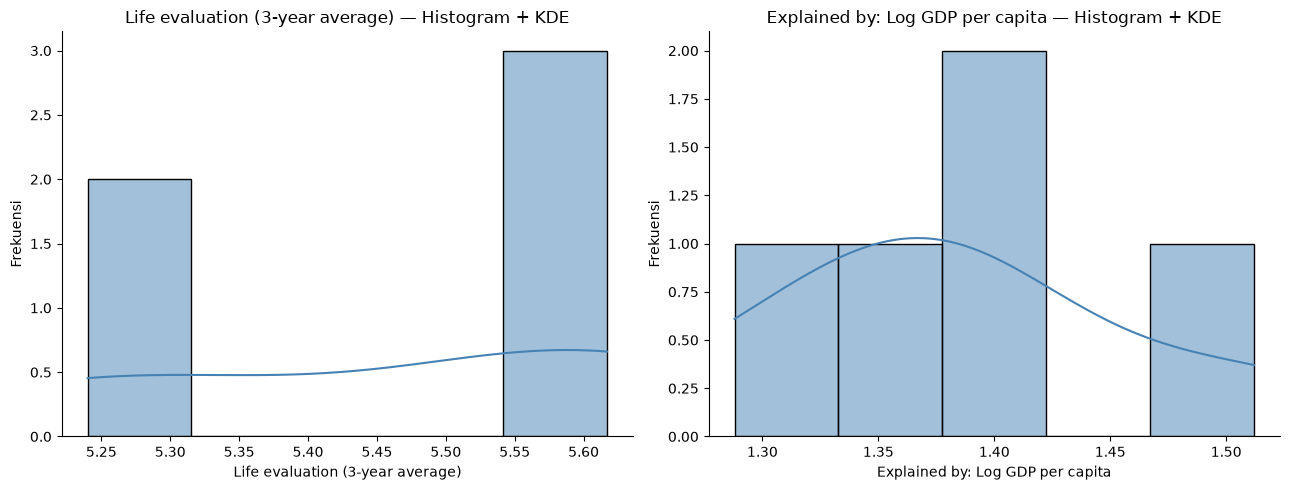

In [21]:
# d. Histogram + KDE — Life Evaluation & Log GDP per capita
cols_kde = [
    'Life evaluation (3-year average)',
    'Explained by: Log GDP per capita'
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, cols_kde):
    sns.histplot(df_idn[col].dropna(), bins=5, kde=True, color='steelblue', ax=ax)
    ax.set_title(f'{col} — Histogram + KDE')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()


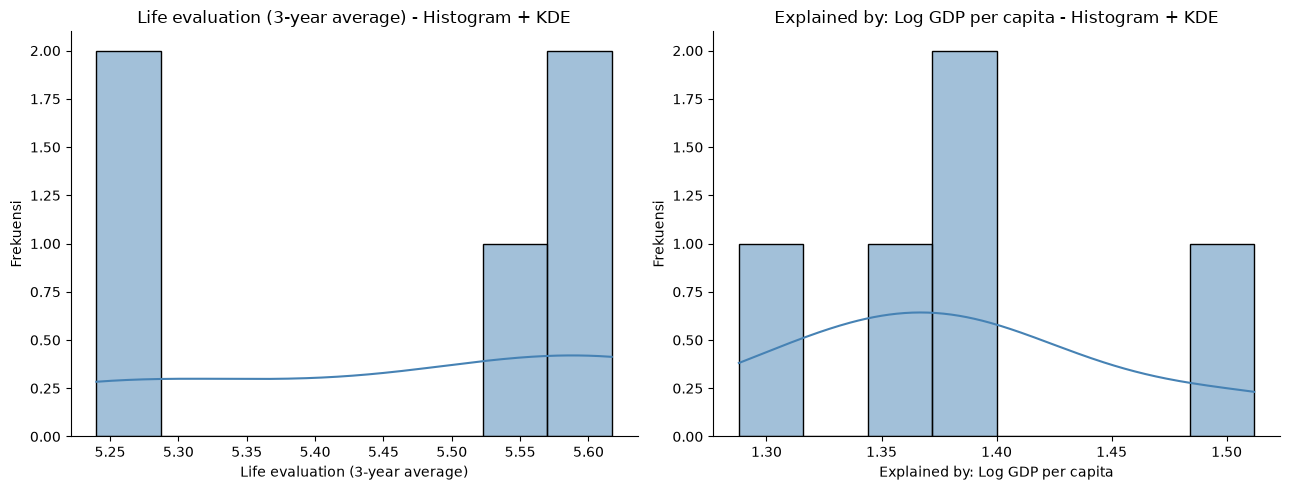

In [22]:
cols_kde = [
    'Life evaluation (3-year average)',
    'Explained by: Log GDP per capita'
]

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5)
)

for ax, col in zip(axes, cols_kde):
    sns.histplot(
        df_idn[col].dropna(),
        bins=8,
        kde=True,
        color='steelblue',
        ax=ax
    )
    
    ax.set_title(
        f'{col} - Histogram + KDE'
    )
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()


**e.** Bandingkan distribusi `Life Evaluation` Indonesia dengan distribusi global tahun **2025**.


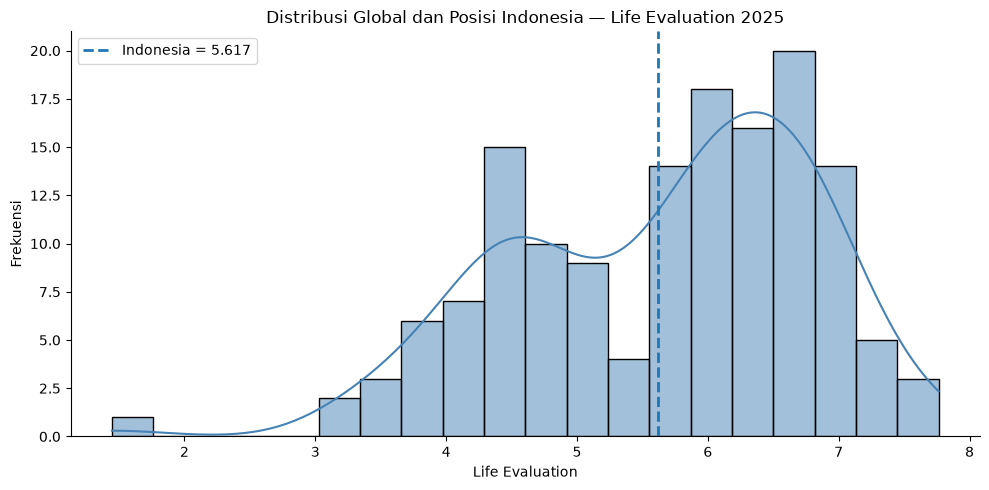

In [23]:
# e. Indonesia vs Global — Life Evaluation 2025
global_2025 = df_whr[df_whr['Year'] == 2025][life_col].dropna()
idn_2025 = df_idn.loc[df_idn['Year'] == 2025, life_col].iloc[0]

plt.figure(figsize=(10, 5))
sns.histplot(global_2025, bins=20, kde=True, color='steelblue')
plt.axvline(idn_2025, linestyle='--', linewidth=2,
            label=f'Indonesia = {idn_2025:.3f}')
plt.title('Distribusi Global dan Posisi Indonesia — Life Evaluation 2025')
plt.xlabel('Life Evaluation')
plt.ylabel('Frekuensi')
plt.legend()
plt.tight_layout()
plt.show()


✏️ **Interpretasi:**

Pada 2025, Life Evaluation Indonesia sebesar **5,617**. Rata-rata global pada tahun yang sama sebesar sekitar **5,650**, sehingga Indonesia berada sedikit di bawah rata-rata global. Pada dataset 2025, Indonesia berada pada **peringkat 87**. Secara visual, posisi Indonesia berada di sekitar bagian tengah distribusi global, bukan pada kelompok nilai tertinggi.


---
# Bagian 5 – Visualisasi & Analisis Hubungan Antar Variabel
Visualisasi yang tepat membantu mengkomunikasikan temuan secara efektif.

## Task 5.1 – Visualisasi Tren & Komparasi

**a.** Line Chart tren `Life Evaluation` Indonesia **2021–2025** dengan anotasi titik tertinggi dan terendah.


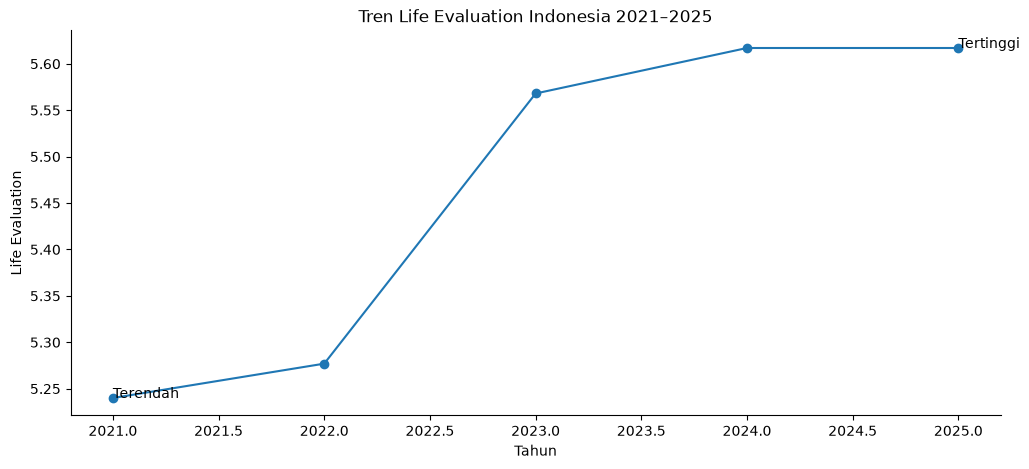

In [24]:
# a. Line Chart — Tren Life Ladder Indonesia
plt.figure(figsize=(12,5))

plt.plot(
    df_idn['Year'],
    df_idn['Life evaluation (3-year average)'],
    marker='o'
)

idx_max = df_idn[
    'Life evaluation (3-year average)'
].idxmax()

idx_min = df_idn[
    'Life evaluation (3-year average)'
].idxmin()

plt.annotate(
    'Tertinggi',
    (
        df_idn.loc[idx_max, 'Year'],
        df_idn.loc[idx_max,
                   'Life evaluation (3-year average)']
    )
)

plt.annotate(
    'Terendah',
    (
        df_idn.loc[idx_min, 'Year'],
        df_idn.loc[idx_min,
                   'Life evaluation (3-year average)']
    )
)

plt.title(
    'Tren Life Evaluation Indonesia 2021–2025'
)

plt.xlabel('Tahun')
plt.ylabel('Life Evaluation')

plt.show()

**b.** Bar Chart — perbandingan **rata-rata Life Evaluation negara-negara ASEAN selama 2021–2025**.


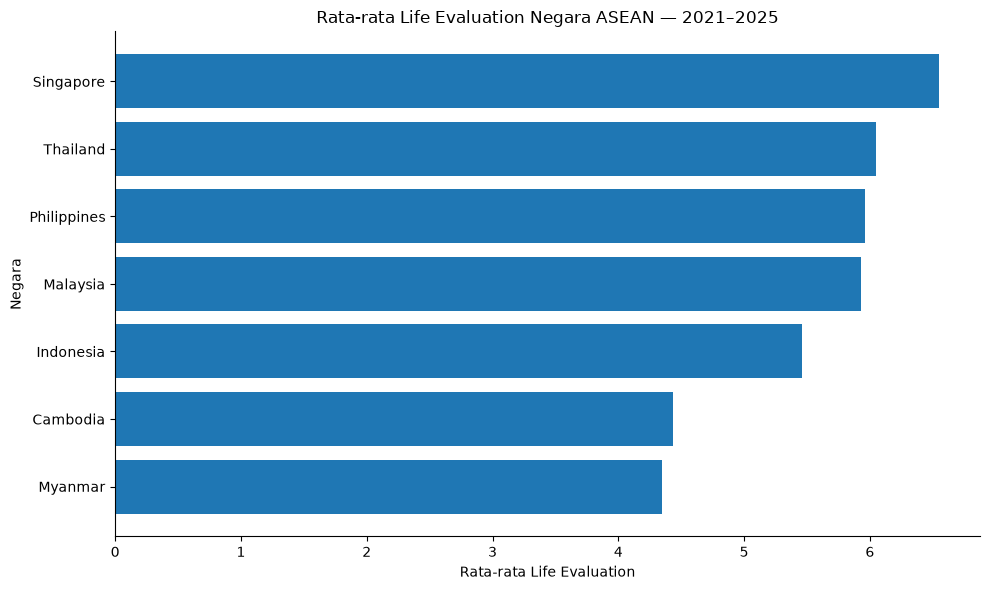

In [25]:
# b. Bar Chart — rata-rata Life Evaluation ASEAN 2021–2025
asean = [
    'Indonesia', 'Thailand', 'Philippines', 'Vietnam', 'Malaysia',
    'Singapore', 'Myanmar', 'Cambodia', 'Laos', 'Brunei Darussalam'
]

asean_avg_5y = (
    df_whr[
        (df_whr['Year'].between(2021, 2025)) &
        (df_whr['Country name'].isin(asean))
    ]
    .groupby('Country name')[life_col]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(asean_avg_5y.index, asean_avg_5y.values)
plt.title('Rata-rata Life Evaluation Negara ASEAN — 2021–2025')
plt.xlabel('Rata-rata Life Evaluation')
plt.ylabel('Negara')
plt.tight_layout()
plt.show()


**c.** ✏️ *Jelaskan kapan sebaiknya menggunakan Line Chart vs Bar Chart:*

Line Chart lebih sesuai untuk menunjukkan perubahan data dari waktu ke waktu karena hubungan antarperiode terlihat jelas melalui garis.
Bar Chart lebih sesuai untuk membandingkan nilai antar kategori, misalnya membandingkan Life Evaluation beberapa negara pada tahun yang sama.

**d.** Heatmap nilai semua variabel numerik Indonesia per tahun.

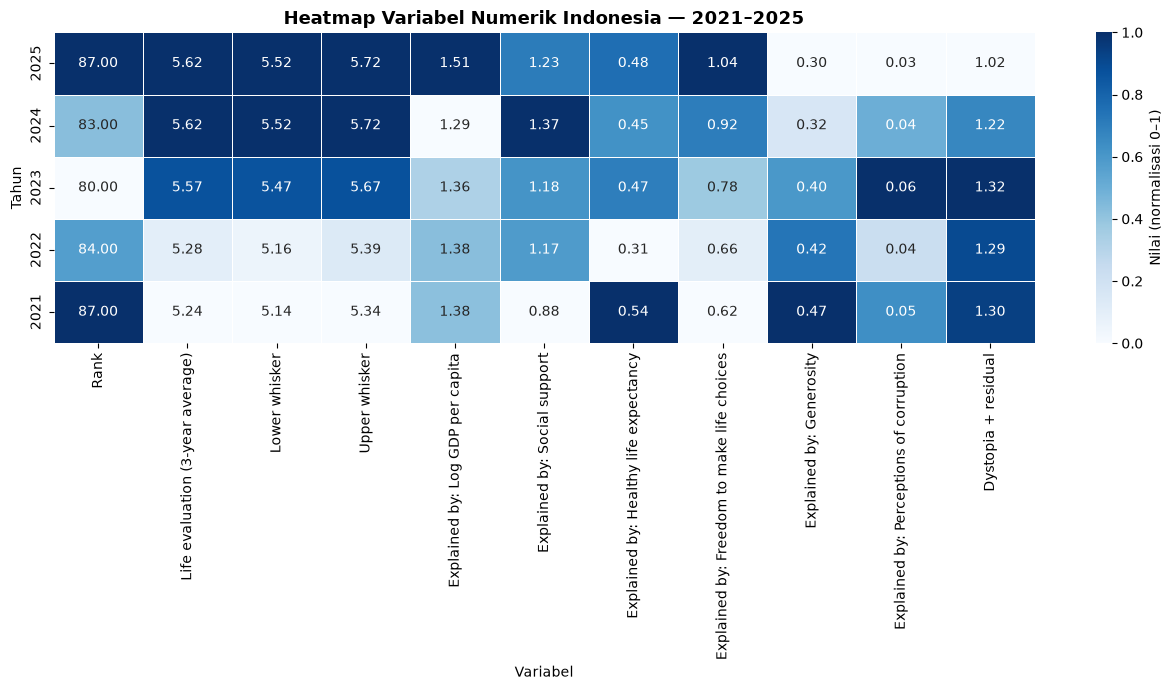

In [26]:
# d. Heatmap nilai variabel numerik Indonesia per tahun
heatmap_data = df_idn.set_index('Year')[numeric_cols]

# Normalisasi 0–1 agar variabel dengan skala berbeda tetap dapat dibandingkan secara visual
heatmap_norm = (
    heatmap_data - heatmap_data.min()
) / (
    heatmap_data.max() - heatmap_data.min()
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(
    heatmap_norm,
    annot=heatmap_data.round(2),
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Nilai (normalisasi 0–1)'}
)
ax.set_title('Heatmap Variabel Numerik Indonesia — 2021–2025', fontsize=13, fontweight='bold')
ax.set_xlabel('Variabel')
ax.set_ylabel('Tahun')
plt.tight_layout()
plt.show()


## Task 5.2 – Analisis Korelasi & Scatter Plot

**a & b.** Scatter Plot 4 pasang variabel + Koefisien Korelasi Pearson.

In [27]:
# a & b. Scatter Plot + Korelasi Pearson
pairs = [
    ('Explained by: Log GDP per capita',
     'Life evaluation (3-year average)'),

    ('Explained by: Social support',
     'Life evaluation (3-year average)'),

    ('Explained by: Healthy life expectancy',
     'Life evaluation (3-year average)'),

    ('Explained by: Freedom to make life choices',
     'Life evaluation (3-year average)')
]

for x, y in pairs:
    data = df_idn[[x, y]].dropna()
    
    r, p = stats.pearsonr(
        data[x],
        data[y]
    )
    
    print(x)
    print("Jumlah data:", len(data))
    print("Pearson r :", round(r, 4))
    print()

Explained by: Log GDP per capita
Jumlah data: 5
Pearson r : 0.0484

Explained by: Social support
Jumlah data: 5
Pearson r : 0.7867

Explained by: Healthy life expectancy
Jumlah data: 5
Pearson r : 0.2171

Explained by: Freedom to make life choices
Jumlah data: 5
Pearson r : 0.8926



✏️ **Interpretasi korelasi:**

| Pasang Variabel | r | Interpretasi |
|---|---:|---|
| Log GDP vs Life Evaluation | 0.048 | Positif sangat lemah |
| Social support vs Life Evaluation | 0.787 | Positif kuat |
| Healthy life expectancy vs Life Evaluation | 0.217 | Positif lemah |
| Freedom vs Life Evaluation | 0.893 | Positif sangat kuat |

Catatan: korelasi dihitung dari **5 observasi (2021–2025)**, sehingga hasil perlu ditafsirkan secara hati-hati dan tidak dapat digunakan sebagai bukti kausalitas.


**c.** Correlation Heatmap semua variabel numerik.

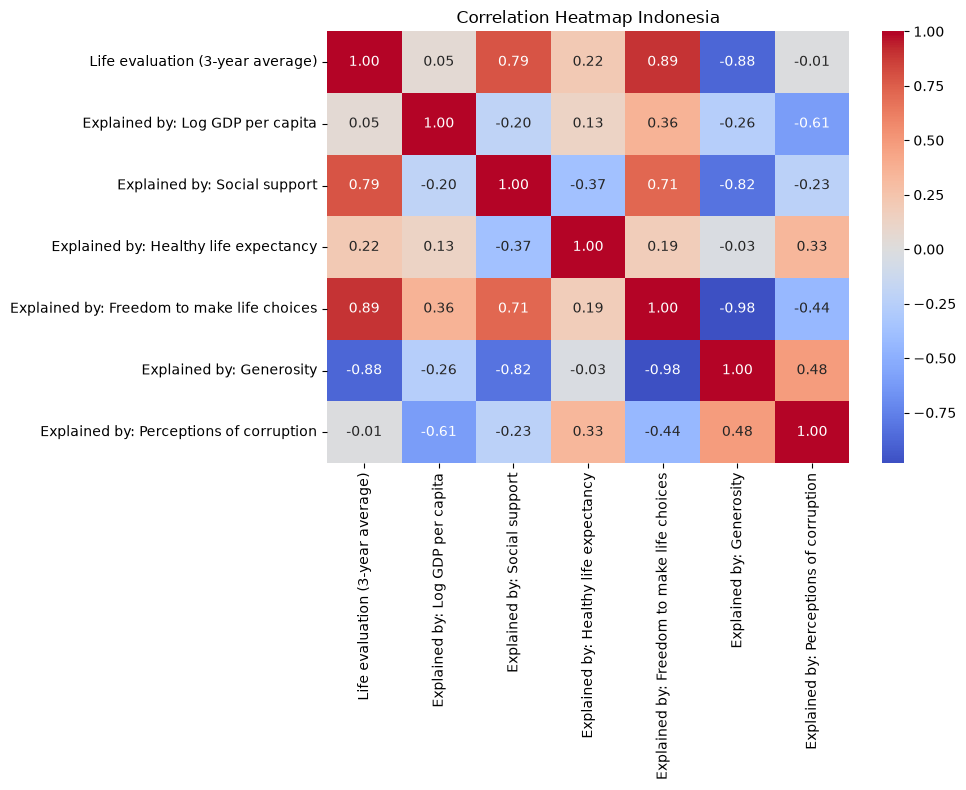

In [28]:
# c. Correlation Heatmap
core_cols = [
    'Life evaluation (3-year average)',
    'Explained by: Log GDP per capita',
    'Explained by: Social support',
    'Explained by: Healthy life expectancy',
    'Explained by: Freedom to make life choices',
    'Explained by: Generosity',
    'Explained by: Perceptions of corruption'
]

corr = df_idn[core_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title(
    'Correlation Heatmap Indonesia'
)

plt.tight_layout()
plt.show()

✏️ **Jawaban:**

Variabel dengan korelasi absolut terbesar terhadap Life Evaluation adalah **Freedom to make life choices**, dengan **r = 0.8926**. Dua variabel berikutnya adalah **Generosity (r = -0.8781)** dan **Social support (r = 0.7867)**.

Hasil ini menunjukkan hubungan linear pada data 2021–2025, bukan bukti bahwa variabel tersebut secara langsung menyebabkan perubahan Life Evaluation.


**d.** ✏️ *Jelaskan perbedaan korelasi dan kausalitas, serta berikan contoh dari data WHR ini:*

Korelasi menunjukkan adanya hubungan antara dua variabel, sedangkan kausalitas menunjukkan bahwa perubahan suatu variabel menyebabkan perubahan variabel lain.

Contohnya, pada data ini terdapat korelasi antara Freedom to make life choices dan Life Evaluation. Namun, korelasi tersebut tidak cukup untuk menyimpulkan bahwa meningkatnya kebebasan secara langsung menyebabkan meningkatnya Life Evaluation karena terdapat faktor lain yang mungkin berpengaruh.

---
# Bagian 6 – Insight & Pelaporan
Analisis yang baik tidak hanya menghasilkan angka, tetapi juga **cerita bermakna** dari data.

## Task 6.1 – Ringkasan Analisis & Insight

**a.** ✏️ **Minimal 5 insight:**

1. **Life Evaluation Indonesia meningkat secara keseluruhan**, dari 5,240 pada 2021 menjadi 5,617 pada 2025, meskipun sempat meningkat dan kemudian stabil.
2. **Rata-rata Life Evaluation Indonesia 2021–2025 adalah 5,464**, dengan nilai tertinggi 5,617 pada 2024 dan 2025.
3. **Indonesia berada di bawah rata-rata global pada 2021–2022 dan 2025**, tetapi sedikit di atas rata-rata global pada 2023–2024.
4. **Tidak ditemukan outlier** pada Life Evaluation Indonesia berdasarkan metode IQR maupun Z-Score.
5. **Freedom to make life choices memiliki korelasi positif sangat kuat (r = 0,893)** dengan Life Evaluation, sedangkan Generosity memiliki korelasi negatif kuat (r = -0,878). Hasil ini bersifat korelasional dan menggunakan lima observasi.
6. Dalam perbandingan ASEAN berdasarkan rata-rata 2021–2025, **Indonesia berada di urutan ke-5 dari 7 negara yang memiliki data pada periode tersebut**.


**b.** Identifikasi 3 variabel yang **paling berkorelasi** dengan `Life Evaluation` Indonesia. Gunakan istilah korelasi, bukan “paling memengaruhi”, karena analisis ini tidak membuktikan kausalitas.


In [29]:
# b. Top 3 variabel paling berkorelasi dengan Life Evaluation
corr_ll = (
    df_idn[core_cols]
    .corr()['Life evaluation (3-year average)']
    .drop('Life evaluation (3-year average)')
    .abs()
    .sort_values(ascending=False)
)

print('Top 3 variabel berdasarkan nilai absolut korelasi:')
display(
    corr_ll.head(3)
    .to_frame('|Korelasi| dengan Life Evaluation')
    .round(4)
)


Top 3 variabel berdasarkan nilai absolut korelasi:


,|Korelasi| dengan Life Evaluation
Explained by: Freedom to make life choices,0.8926
Explained by: Generosity,0.8781
Explained by: Social support,0.7867


✏️ **Interpretasi:**

Tiga variabel dengan hubungan linear terkuat berdasarkan nilai absolut korelasi adalah **Freedom to make life choices (r = 0.8926)**, **Generosity (r = -0.8781)**, dan **Social support (r = 0.7867)**. Karena hanya terdapat lima observasi, hasil ini sebaiknya dipandang sebagai temuan deskriptif awal dan perlu diuji dengan data yang lebih panjang untuk memperoleh kesimpulan yang lebih kuat.


**c.** ✏️ **Tren kebahagiaan Indonesia:**

Berdasarkan periode 2021–2025, Life Evaluation Indonesia **cenderung meningkat**, dari 5,240 pada 2021 menjadi 5,617 pada 2025. Namun, peningkatan tidak terjadi setiap tahun: nilai naik pada 2022–2024 dan kemudian relatif stabil pada 2025.


**d.** Peringkat Indonesia di antara negara ASEAN berdasarkan **rata-rata Life Evaluation 2021–2025**.


In [30]:
# d. Ranking Indonesia di ASEAN berdasarkan rata-rata 2021–2025
asean_avg = (
    df_whr[
        (df_whr['Country name'].isin(asean)) &
        (df_whr['Year'].between(2021, 2025))
    ]
    .groupby('Country name')[life_col]
    .mean()
    .sort_values(ascending=False)
)

display(asean_avg.round(3))

rank_idn = asean_avg.index.tolist().index('Indonesia') + 1
print('Rata-rata Indonesia:', round(asean_avg['Indonesia'], 3))
print(f'Peringkat Indonesia: {rank_idn} dari {len(asean_avg)} negara yang memiliki data')


Country name
Singapore      6.548
Thailand       6.046
Philippines    5.958
Malaysia       5.932
Indonesia      5.464
Cambodia       4.435
Myanmar        4.346
Name: Life evaluation (3-year average), dtype: float64

Rata-rata Indonesia: 5.464
Peringkat Indonesia: 5 dari 7 negara yang memiliki data


**e.** ✏️ **Rekomendasi:**

1. **Pendalaman faktor kebebasan dan dukungan sosial.** Karena Freedom to make life choices dan Social support menunjukkan korelasi positif yang cukup kuat, analisis lanjutan dapat mengevaluasi indikator sosial yang berkaitan dengan persepsi kebebasan dan dukungan sosial masyarakat.
2. **Pemantauan tren secara berkelanjutan.** Karena Life Evaluation meningkat dari 2021 hingga 2025 tetapi tidak naik setiap tahun, pengamatan berkala dan analisis dengan periode lebih panjang diperlukan untuk memahami faktor yang berkaitan dengan perubahan tersebut.

Rekomendasi di atas merupakan implikasi dari analisis deskriptif/korelasi dan bukan bukti bahwa faktor tersebut secara langsung menyebabkan perubahan kebahagiaan.


## Task 6.2 – Export Notebook ke PDF

Jalankan perintah berikut di **Terminal** (bukan di dalam notebook) untuk mengekspor:

```bash
jupyter nbconvert --to pdf nama_notebook_anda.ipynb
```

> **Alternatif:** Di Jupyter Notebook → `File` → `Export Notebook As` → `PDF`  
> **Atau:** Di Jupyter Lab → `File` → `Save and Export Notebook As` → `PDF`

---
## 📝 Kesimpulan Akhir

✏️ **Kesimpulan Akhir**

**Paragraf 1 — Gambaran umum:**
Analisis menggunakan data World Happiness Report 2026 untuk Indonesia pada periode 2021–2025 dengan indikator Life evaluation (3-year average). Nilai Life Evaluation Indonesia berkisar antara 5,240 hingga 5,617, dengan rata-rata 5,464.

**Paragraf 2 — Central tendency & dispersi:**
Mean sebesar 5,4638 dan median sebesar 5,5680. Standard deviation sebesar 0,1889, dengan IQR sebesar 0,3400 dan coefficient of variation sebesar 3,46%. Berdasarkan IQR dan CV, Life Evaluation memiliki variasi yang relatif terbatas selama periode pengamatan.

**Paragraf 3 — Distribusi & korelasi:**
Distribusi Life Evaluation memiliki skewness -0,5811 sehingga cenderung left-skewed berdasarkan batas sederhana yang digunakan. Tidak ditemukan outlier melalui metode IQR maupun Z-Score. Korelasi terbesar berdasarkan nilai absolut adalah Freedom to make life choices (r = 0,8926), Generosity (r = -0,8781), dan Social support (r = 0,7867). Korelasi tersebut tidak membuktikan hubungan sebab-akibat.

**Paragraf 4 — Global & ASEAN:**
Indonesia berada di bawah rata-rata global pada 2021–2022 dan 2025, serta sedikit di atas rata-rata global pada 2023–2024. Berdasarkan rata-rata 2021–2025, Indonesia berada pada urutan ke-5 dari 7 negara ASEAN yang memiliki data dalam dataset.

**Paragraf 5 — Penutup:**
Secara keseluruhan, Life Evaluation Indonesia cenderung meningkat dari 2021 hingga 2025, meskipun terdapat fluktuasi. Hasil ini memberikan gambaran deskriptif mengenai kondisi evaluasi kehidupan Indonesia. Analisis lanjutan dengan lebih banyak tahun dan metode inferensial diperlukan untuk menguji hubungan antarvariabel secara lebih kuat.
